In [1]:
from graphviz import Digraph
import math


In [41]:
class Value:
    def __init__(self, data, _children=(), _op='', _label=''):
        self.data = data
        self._prev = set(_children)
        self._grad = 0.0
        self._backward = lambda: None
        self._op = _op
        self._label = _label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self._grad += 1.0 * out._grad
            other._grad += 1.0 * out._grad 
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self._grad += other.data * out._grad
            other._grad += self.data * out._grad
        out._backward = _backward
        return out
    def __rmul__(self, other):
        return self * other
    def __sub__(self, other):
        return self + (-other) 
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self._grad += other * (self.data ** (other-1)) * out._grad
        out._backward = _backward
        return out


    def __truediv__(self, other):
        return self * other
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self._grad = out.data * out._grad
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self._grad += (1 - t**2) * out._grad
        out._backward = _backward
        return out
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self._grad = 1.0
        for node in reversed(topo):
            node._backward()



In [19]:
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n._label, n.data, n._grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [4]:
a = Value(2.0, _label='a')
b = Value(-3.0, _label='b')
c = Value(10.0, _label='c')
e = a*b; e._label = 'e'
d = e+c; d._label = 'd'
f = Value(-2.0, _label='f')
L = d*f; L._label = 'L'

In [5]:
def lol():
    h = 0.0001

    a = Value(2.0, _label='a')
    b = Value(-3.0, _label='b')
    c = Value(10.0, _label='c')
    e = a*b; e._label = 'e'
    d = e+c; d._label = 'd'
    f = Value(-2.0, _label='f')
    L = d*f; L._label = 'L'
    L1 = L.data

    a = Value(2.0 + h, _label='a')
    b = Value(-3.0, _label='b')
    c = Value(10.0, _label='c')
    e = a*b; e._label = 'e'
    d = e+c; d._label = 'd'
    f = Value(-2.0, _label='f')
    L = d*f; L._label = 'L'
    L2 = L.data
    
    print((L2 - L1)/h)

lol()


6.000000000021544


In [20]:
L = d * f
L._grad = 1.0
f._grad = d.data * L._grad
d._grad = f.data * L._grad

# d = e + c
# c = d - e
# dL/dc = dL/dd  * dd/dc

# dd/dc = e + c = c = 1
dddc = 1.0
dLdd = d._grad
dLdc = dLdd * dddc
c._grad = dLdc
e._grad = dLdd * 1.0
 
# dL / de = -2.0
# dL / da = (dL / de) * (de / da)
dLde = e._grad
deda = b.data
dLda = dLde * deda
a._grad = dLda
b._grad = dLde * a.data

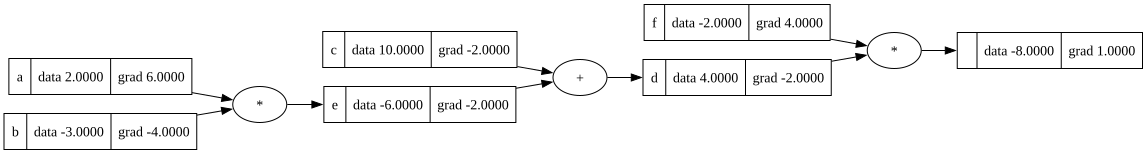

In [7]:
draw_dot(L)

In [42]:
# inputs x1,x2
x1 = Value(2.0, _label='x1')
x2 = Value(0.0, _label='x2')
# weights w1,w2
w1 = Value(-3.0, _label='w1')
w2 = Value(1.0, _label='w2')
# bias of the neuron
b = Value(6.881373, _label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1._label = 'x1*w1'
x2w2 = x2*w2; x2w2._label='x2*w2'
x1w1x2w2 = x1w1 +x2w2; x1w1x2w2._label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n._label = 'n'
o = n.tanh(); o._label = 'o'

In [ ]:
o._grad = 1.0


In [ ]:
o._backward()

In [31]:
n._backward()

In [33]:
x1w1x2w2._backward()

In [35]:
x1w1._backward()
x2w2._backward()

In [ ]:
o.backward()

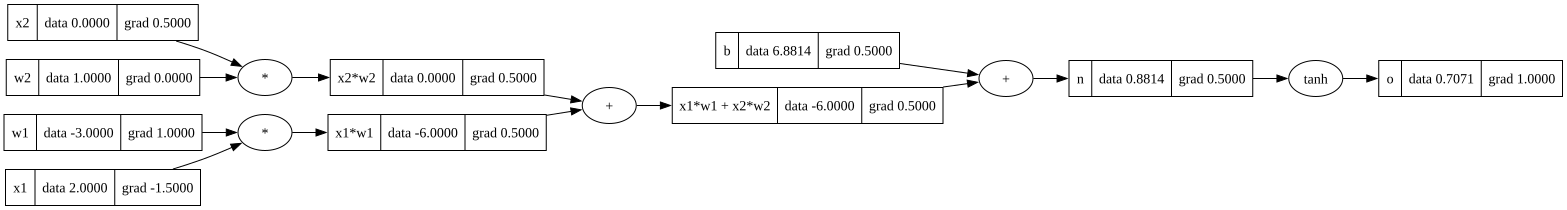

In [40]:
draw_dot(o)

In [16]:
o._grad = 1.0
x1w1._grad = 0.5
x2w2._grad = 0.5
x1w1x2w2._grad = 0.5
b._grad = 0.5
n._grad = 0.5
o._grad = 1.0 

x1._grad = w1.data * x1w1._grad
w1._grad = x1.data * x1w1._grad
x2._grad = w2.data * x2w2._grad
w2._grad = x2.data * x2w2._grad


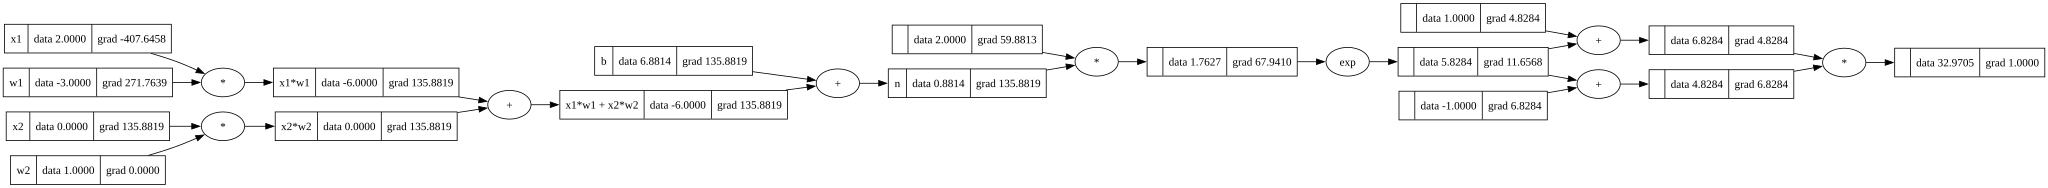

In [43]:
# inputs x1,x2
x1 = Value(2.0, _label='x1')
x2 = Value(0.0, _label='x2')
# weights w1,w2
w1 = Value(-3.0, _label='w1')
w2 = Value(1.0, _label='w2')
# bias of the neuron
b = Value(6.881373, _label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1._label = 'x1*w1'
x2w2 = x2*w2; x2w2._label='x2*w2'
x1w1x2w2 = x1w1 +x2w2; x1w1x2w2._label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n._label = 'n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'
o.backward()
draw_dot(o)

In [44]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor( [6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print(' --- ')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())



0.7071066904050358
 --- 
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)


[(Value(data=0.5125503712709458), 2.0), (Value(data=0.19610198202944296), 3.0)]


0.0